# 🧠 Brain Tumor Segmentation với Attention U-Net (TensorFlow)

**Dataset:** `anhxunv/brain-turmor-segment-datasets`  
**Task:** Binary Segmentation (tumor vs background)  
**Model:** Attention U-Net (Oktay et al., 2018)  
**Framework:** TensorFlow / Keras  
**Hardware:** 2x GPU T4 (MirroredStrategy) + Mixed Precision float16

**Metrics đánh giá:**
- Dice Score (F1)
- IoU (Intersection over Union)
- Precision & Recall
- Tổng số tham số model


## Cell 1 — Cài đặt & Import thư viện

In [1]:
!pip install -q kagglehub

import os
import numpy as np
import matplotlib.pyplot as plt
import cv2
from glob import glob
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import ResNet50V2
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping

print(f'TensorFlow version: {tf.__version__}')
print(f'GPUs available: {tf.config.list_physical_devices("GPU")}')


2026-06-17 01:54:42.298911: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781661282.564958      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781661282.637970      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781661283.290479      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781661283.290515      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781661283.290517      58 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0
GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


## Cell 2 — Load Dataset

In [2]:
import kagglehub

# Download dataset
path = kagglehub.dataset_download("anhxunv/brain-turmor-segment-datasets")
print("Path to dataset files:", path)

# Scan cấu trúc thư mục
print("\n📁 Cấu trúc thư mục:")
for root, dirs, files in os.walk(path):
    level = root.replace(path, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    if level < 3:  # chỉ in 3 level đầu
        subindent = ' ' * 2 * (level + 1)
        for f in files[:5]:  # in tối đa 5 file
            print(f'{subindent}{f}')
        if len(files) > 5:
            print(f'{subindent}... ({len(files)} files total)')

Path to dataset files: /kaggle/input/datasets/anhxunv/brain-turmor-segment-datasets

📁 Cấu trúc thư mục:
brain-turmor-segment-datasets/
  datasets/
    mask/
      Tr-me_0529.jpg
      Tr-pi_0282.jpg
      2664.png
      2539.png
      Tr-pi_0972.jpg
      ... (5706 files total)
    image/
      Tr-me_0529.jpg
      Tr-pi_0282.jpg
      2664.png
      2539.png
      Tr-pi_0972.jpg
      ... (5706 files total)


📊 Thống kê dataset:
  Tổng số ảnh gốc : 5706
  Tổng số mask    : 5706
  Sample image shape : (512, 512, 3)
  Sample mask shape  : (512, 512)
  Mask unique values : [  0 255]


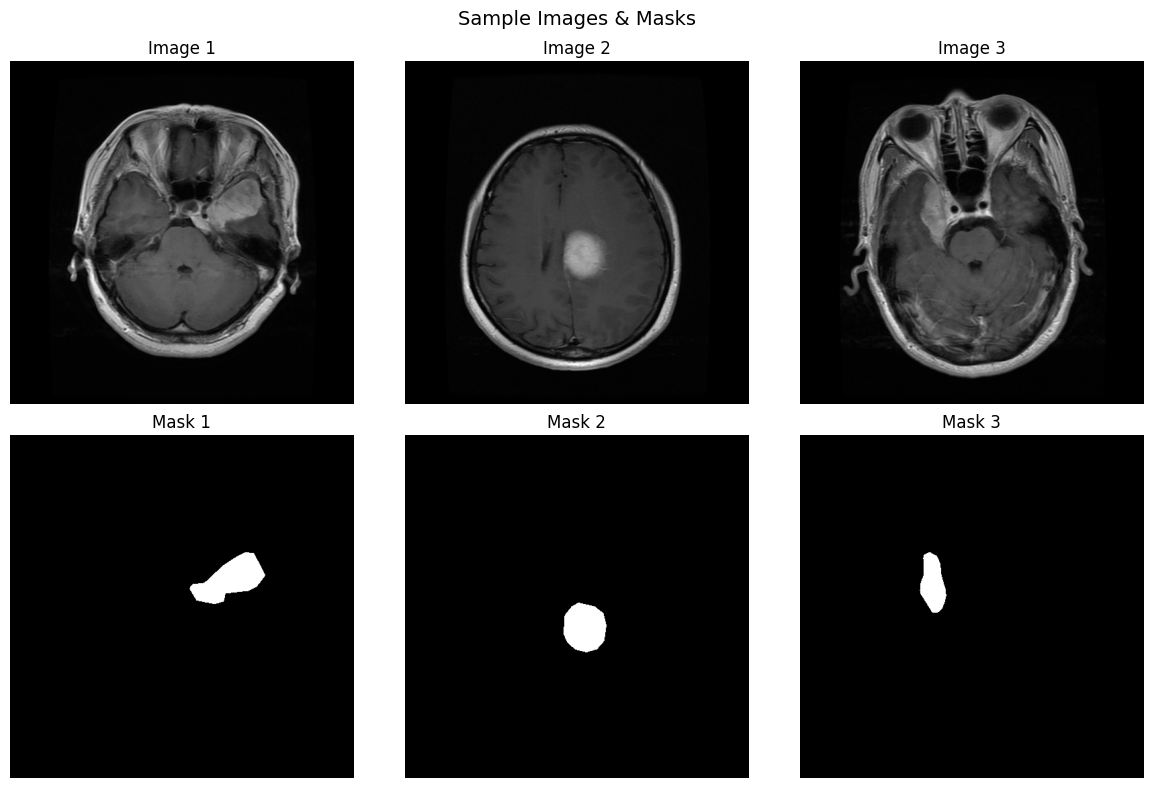

In [3]:
# --- Tìm ảnh và mask theo cấu trúc thư mục image/ và mask/ ---
image_dir = os.path.join(path, 'datasets', 'image')
mask_dir  = os.path.join(path, 'datasets', 'mask')

IMAGE_EXTENSIONS = ('.png', '.jpg', '.jpeg')

def get_sorted_files(folder):
    files = [
        os.path.join(folder, f)
        for f in sorted(os.listdir(folder))
        if f.lower().endswith(IMAGE_EXTENSIONS)
    ]
    return files

image_files = get_sorted_files(image_dir)
mask_files  = get_sorted_files(mask_dir)

# Verify tên file khớp nhau
assert len(image_files) == len(mask_files), 'Số ảnh và mask không khớp!'
for img_f, mask_f in zip(image_files[:5], mask_files[:5]):
    assert os.path.basename(img_f) == os.path.basename(mask_f), \
        f'Tên file không khớp: {os.path.basename(img_f)} vs {os.path.basename(mask_f)}'

print(f'📊 Thống kê dataset:')
print(f'  Tổng số ảnh gốc : {len(image_files)}')
print(f'  Tổng số mask    : {len(mask_files)}')

# Kiểm tra shape
sample_img  = cv2.imread(image_files[0])
sample_mask = cv2.imread(mask_files[0], cv2.IMREAD_GRAYSCALE)
print(f'  Sample image shape : {sample_img.shape}')
print(f'  Sample mask shape  : {sample_mask.shape}')
print(f'  Mask unique values : {np.unique(sample_mask)}')

# Visualize 3 sample
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for i in range(3):
    img  = cv2.cvtColor(cv2.imread(image_files[i]), cv2.COLOR_BGR2RGB)
    mask = cv2.imread(mask_files[i], cv2.IMREAD_GRAYSCALE)
    axes[0, i].imshow(img)
    axes[0, i].set_title(f'Image {i+1}')
    axes[0, i].axis('off')
    axes[1, i].imshow(mask, cmap='gray')
    axes[1, i].set_title(f'Mask {i+1}')
    axes[1, i].axis('off')
plt.suptitle('Sample Images & Masks', fontsize=14)
plt.tight_layout()
plt.show()

## Cell 3 — Build Attention U-Net (paper gốc Oktay et al., 2018)

In [4]:
# ============================================================
# Attention U-Net (Oktay et al., 2018)
# Paper: https://arxiv.org/abs/1804.03999
# Thêm Attention Gate vào skip connections của U-Net gốc
# ============================================================

IMG_SIZE     = 256
NUM_CHANNELS = 3
NUM_CLASSES  = 1

def conv_block(x, filters):
    """2x (Conv2D → BN → ReLU)"""
    x = layers.Conv2D(filters, 3, padding='same', kernel_initializer='he_normal')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(filters, 3, padding='same', kernel_initializer='he_normal')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    return x

def encoder_block(x, filters):
    """Conv block + MaxPool. Trả về (skip, pooled)"""
    skip   = conv_block(x, filters)
    pooled = layers.MaxPooling2D(2)(skip)
    return skip, pooled

def attention_gate(x, g, filters):
    """
    x: skip connection từ encoder
    g: gating signal từ decoder (cùng spatial size với x sau khi upsample)
    """
    theta_x = layers.Conv2D(filters, 1, padding='same')(x)
    phi_g   = layers.Conv2D(filters, 1, padding='same')(g)

    # Không cần upsample vì g đã cùng size với x sau Conv2DTranspose
    add   = layers.Add()([theta_x, phi_g])
    act   = layers.Activation('relu')(add)
    psi   = layers.Conv2D(1, 1, padding='same')(act)
    alpha = layers.Activation('sigmoid')(psi)

    return layers.Multiply()([x, alpha])

def decoder_block(x, skip, filters):
    """
    Upsample → Attention Gate(skip, x) → Concat → Conv block
    Khác U-Net thường: skip được lọc qua attention trước khi concat
    """
    x            = layers.Conv2DTranspose(filters, 2, strides=2, padding='same')(x)
    skip_attended = attention_gate(skip, x, filters // 2)
    x            = layers.Concatenate()([x, skip_attended])
    x            = conv_block(x, filters)
    return x

def build_attention_unet(input_shape=(IMG_SIZE, IMG_SIZE, NUM_CHANNELS)):
    inputs = layers.Input(shape=input_shape)

    # ---- Encoder (Contracting Path) ----
    s1, p1 = encoder_block(inputs, 64)   # 256→128
    s2, p2 = encoder_block(p1,     128)  # 128→64
    s3, p3 = encoder_block(p2,     256)  # 64→32
    s4, p4 = encoder_block(p3,     512)  # 32→16

    # ---- Bottleneck ----
    b = conv_block(p4, 1024)             # 16×16×1024

    # ---- Decoder (Expanding Path) + Attention Gates ----
    d1 = decoder_block(b,  s4, 512)     # 16→32
    d2 = decoder_block(d1, s3, 256)     # 32→64
    d3 = decoder_block(d2, s2, 128)     # 64→128
    d4 = decoder_block(d3, s1, 64)      # 128→256

    # ---- Output ----
    outputs = layers.Conv2D(NUM_CLASSES, 1, activation='sigmoid')(d4)

    model = Model(inputs, outputs, name='Attention-UNet')
    return model


## Cell 4 — Mô tả Model & Đếm tham số

In [5]:
temp_model = build_attention_unet()

trainable_params     = np.sum([np.prod(v.shape) for v in temp_model.trainable_weights])
non_trainable_params = np.sum([np.prod(v.shape) for v in temp_model.non_trainable_weights])
total_params         = trainable_params + non_trainable_params

print('=' * 70)
print('           THÔNG TIN MODEL: Attention U-Net')
print('=' * 70)
print(f'  Kiến trúc      : Attention U-Net (Oktay et al., 2018)')
print(f'  Input shape    : ({IMG_SIZE}, {IMG_SIZE}, {NUM_CHANNELS})')
print(f'  Output shape   : ({IMG_SIZE}, {IMG_SIZE}, {NUM_CLASSES})')
print(f'  Task           : Binary Segmentation (sigmoid output)')
print(f'  Encoder        : 4 levels (64→128→256→512) + MaxPool')
print(f'  Bottleneck     : 1024 filters')
print(f'  Decoder        : 4 levels (512→256→128→64)')
print(f'  Attention Gates: 4 (1 per skip connection)')
print(f'  Skip conns     : filtered qua Attention Gate trước khi concat')
print(f'  Encoder weights: random init (train from scratch)')
print(f'  Activation     : ReLU (hidden), Sigmoid (output + attention)')
print(f'  Norm           : Batch Normalization')
print('=' * 70)
print(f'  Trainable params    : {trainable_params:>15,}')
print(f'  Non-trainable params: {non_trainable_params:>15,}')
print(f'  TỔNG SỐ THAM SỐ    : {total_params:>15,}')
print('=' * 70)

print('\n📋 Layer-by-layer Summary:')
temp_model.summary()

del temp_model


I0000 00:00:1781661385.457330      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1781661385.463471      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


           THÔNG TIN MODEL: Attention U-Net
  Kiến trúc      : Attention U-Net (Oktay et al., 2018)
  Input shape    : (256, 256, 3)
  Output shape   : (256, 256, 1)
  Task           : Binary Segmentation (sigmoid output)
  Encoder        : 4 levels (64→128→256→512) + MaxPool
  Bottleneck     : 1024 filters
  Decoder        : 4 levels (512→256→128→64)
  Attention Gates: 4 (1 per skip connection)
  Skip conns     : filtered qua Attention Gate trước khi concat
  Encoder weights: random init (train from scratch)
  Activation     : ReLU (hidden), Sigmoid (output + attention)
  Norm           : Batch Normalization
  Trainable params    :      31,393,125
  Non-trainable params:          11,776
  TỔNG SỐ THAM SỐ    :      31,404,901

📋 Layer-by-layer Summary:


Model: "Attention-UNet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │      1,792 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 256, 256,  │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │     36,928 │ activation[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │     73,856 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        512 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │    147,584 │ activation_2[0][… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        512 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ activation_3[0][… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │    295,168 │ max_pooling2d_1[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │      1,024 │ conv2d_4[0][0]  

 Total params: 31,404,901 (119.80 MB)

 Trainable params: 31,393,125 (119.76 MB)

 Non-trainable params: 11,776 (46.00 KB)

## Cell 5 — Định nghĩa Metrics & Loss

In [6]:
SMOOTH = 1e-6

def dice_coeff(y_true, y_pred):
    y_true_f = tf.cast(tf.reshape(y_true, [-1]), tf.float32)
    y_pred_f = tf.cast(tf.reshape(y_pred, [-1]), tf.float32)
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return (2.0 * intersection + SMOOTH) / (tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + SMOOTH)

def dice_loss(y_true, y_pred):
    return 1.0 - dice_coeff(y_true, y_pred)

def bce_dice_loss(y_true, y_pred):
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    return bce + dice_loss(y_true, y_pred)

def iou_metric(y_true, y_pred):
    y_true_f = tf.cast(tf.reshape(y_true, [-1]), tf.float32)
    y_pred_f = tf.cast(tf.reshape(tf.round(y_pred), [-1]), tf.float32)
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    union = tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) - intersection
    return (intersection + SMOOTH) / (union + SMOOTH)

def precision_metric(y_true, y_pred):
    y_true_f = tf.cast(tf.reshape(y_true, [-1]), tf.float32)
    y_pred_f = tf.cast(tf.reshape(tf.round(y_pred), [-1]), tf.float32)
    tp = tf.reduce_sum(y_true_f * y_pred_f)
    fp = tf.reduce_sum((1 - y_true_f) * y_pred_f)
    return (tp + SMOOTH) / (tp + fp + SMOOTH)

def recall_metric(y_true, y_pred):
    y_true_f = tf.cast(tf.reshape(y_true, [-1]), tf.float32)
    y_pred_f = tf.cast(tf.reshape(tf.round(y_pred), [-1]), tf.float32)
    tp = tf.reduce_sum(y_true_f * y_pred_f)
    fn = tf.reduce_sum(y_true_f * (1 - y_pred_f))
    return (tp + SMOOTH) / (tp + fn + SMOOTH)

print('✅ Đã định nghĩa: dice_coeff, iou_metric, precision_metric, recall_metric')
print('✅ Loss function: BCE + Dice Loss')

✅ Đã định nghĩa: dice_coeff, iou_metric, precision_metric, recall_metric
✅ Loss function: BCE + Dice Loss


## Cell 6 — Dataset & DataLoader

In [7]:
BATCH_SIZE =  32  # tổng (chia đều cho 2 GPU -> 8 mỗi GPU)
AUTOTUNE = tf.data.AUTOTUNE

def load_and_preprocess(img_path, mask_path):
    img = tf.io.read_file(img_path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32) / 255.0
    mask = tf.io.read_file(mask_path)
    mask = tf.image.decode_image(mask, channels=1, expand_animations=False)
    mask = tf.image.resize(mask, [IMG_SIZE, IMG_SIZE], method='nearest')
    mask = tf.cast(mask, tf.float32) / 255.0
    mask = tf.round(mask)
    return img, mask

def augment(img, mask):
    if tf.random.uniform(()) > 0.5:
        img = tf.image.flip_left_right(img)
        mask = tf.image.flip_left_right(mask)
    if tf.random.uniform(()) > 0.5:
        img = tf.image.flip_up_down(img)
        mask = tf.image.flip_up_down(mask)
    img = tf.image.random_brightness(img, 0.1)
    img = tf.clip_by_value(img, 0.0, 1.0)
    return img, mask

# Train/Val/Test split: 80/10/10
img_train, img_temp, mask_train, mask_temp = train_test_split(
    image_files, mask_files, test_size=0.2, random_state=42
)
img_val, img_test, mask_val, mask_test = train_test_split(
    img_temp, mask_temp, test_size=0.5, random_state=42
)

print(f'📊 Dataset split:')
print(f'  Train : {len(img_train)} samples')
print(f'  Val   : {len(img_val)} samples')
print(f'  Test  : {len(img_test)} samples')

def make_dataset(img_paths, mask_paths, augment_data=False):
    ds = tf.data.Dataset.from_tensor_slices((img_paths, mask_paths))
    ds = ds.map(load_and_preprocess, num_parallel_calls=AUTOTUNE)
    ds = ds.cache()                    # ← cache vào RAM sau lần load đầu
    if augment_data:
        ds = ds.map(augment, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

train_ds = make_dataset(img_train, mask_train, augment_data=True)
val_ds   = make_dataset(img_val, mask_val)
test_ds  = make_dataset(img_test, mask_test)

print(f'\n✅ DataLoader ready!')
print(f'  Batch size  : {BATCH_SIZE} (8 per GPU)')
print(f'  Cache       : enabled (RAM ~4-5GB)')
print(f'  Train steps : {len(img_train) // BATCH_SIZE} steps/epoch')


📊 Dataset split:
  Train : 4564 samples
  Val   : 571 samples
  Test  : 571 samples

✅ DataLoader ready!
  Batch size  : 32 (8 per GPU)
  Cache       : enabled (RAM ~4-5GB)
  Train steps : 142 steps/epoch


## Cell 7 — Setup 2 GPU & Compile Model (+ Auto-Resume Checkpoint)

In [ ]:
import json, time
from tensorflow.keras import mixed_precision

# ---- Mixed Precision float16 ----
mixed_precision.set_global_policy('mixed_float16')
print(f'✅ Mixed precision policy: {mixed_precision.global_policy().name}')

# ---- Thông tin GPU ----
gpus = tf.config.list_physical_devices('GPU')
print(f'🖥️  Số GPU phát hiện: {len(gpus)}')
for i, gpu in enumerate(gpus):
    gpu_details = tf.config.experimental.get_device_details(gpu)
    print(f'   GPU {i}: {gpu_details.get("device_name", gpu.name)}')

# ---- MirroredStrategy cho multi-GPU ----
strategy = tf.distribute.MirroredStrategy()
print(f'\n⚡ MirroredStrategy: {strategy.num_replicas_in_sync} GPU(s) đang được dùng')

# ============================================================
# 🔄 AUTO-RESUME: lưu checkpoint MỖI epoch + tự nhậ n diện
# để tiếp tục đúng epoch nếu máy bị treo/crash/tắt giềa chừng
# ============================================================
CHECKPOINT_DIR  = '/kaggle/working/checkpoints'              # checkpoint từng epoch
CHECKPOINT_PATH = '/kaggle/working/best_unet_model.keras'    # model tốt nhất (val_dice_coeff)
STATE_PATH      = os.path.join(CHECKPOINT_DIR, 'last_state.json')
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

class RobustCheckpoint(keras.callbacks.Callback):
    """Lưu model + ghi rõ số epoch ra file json sau MỖI epoch.
    Nhờ vậy dù máy bị treo/crash giữa chừng, mở notebook lại
    vẫn biết chính xác đã train tới epoch nào để resume tiếp."""

    def __init__(self, checkpoint_dir, keep_last=2):
        super().__init__()
        self.checkpoint_dir = checkpoint_dir
        self.keep_last = keep_last

    def on_epoch_end(self, epoch, logs=None):
        ckpt_path = os.path.join(self.checkpoint_dir, f"model_epoch_{epoch+1:03d}.keras")
        self.model.save(ckpt_path)

        state = {
            "epoch": epoch + 1,
            "checkpoint_file": ckpt_path,
            "logs": {k: float(v) for k, v in (logs or {}).items()},
            "timestamp": time.strftime("%Y-%m-%d %H:%M:%S"),
        }
        with open(os.path.join(self.checkpoint_dir, "last_state.json"), "w") as f:
            json.dump(state, f, indent=2)

        print(f"💾 Đã lưu checkpoint epoch {epoch+1} -> {ckpt_path}")
        self._cleanup_old()

    def _cleanup_old(self):
        files = sorted(
            [f for f in os.listdir(self.checkpoint_dir) if f.startswith("model_epoch_")],
            key=lambda x: int(x.split("_")[-1].split(".")[0])
        )
        for f in files[:-self.keep_last]:
            os.remove(os.path.join(self.checkpoint_dir, f))

custom_objects = {
    'bce_dice_loss': bce_dice_loss,
    'dice_coeff': dice_coeff,
    'iou_metric': iou_metric,
    'precision_metric': precision_metric,
    'recall_metric': recall_metric
}

initial_epoch = 0
with strategy.scope():
    if os.path.exists(STATE_PATH):
        with open(STATE_PATH) as f:
            saved_state = json.load(f)
        print(f"\n🔄 Phát hiện checkpoint cũ ở epoch {saved_state['epoch']}")
        print(f"   Đang load lại model từ: {saved_state['checkpoint_file']}")
        model = keras.models.load_model(saved_state['checkpoint_file'], custom_objects=custom_objects)
        initial_epoch = saved_state['epoch']
    else:
        print("\n🆕 Không có checkpoint cũ, build model mới từ đầu")
        model = build_attention_unet()
        model.compile(
            optimizer=keras.optimizers.Adam(learning_rate=2e-4),
            loss=bce_dice_loss,
            metrics=[dice_coeff, iou_metric, precision_metric, recall_metric]
        )

print(f'\n✅ Model sẵn sàng!')
print(f'   Architecture     : Attention U-Net (Oktay et al., 2018)')
print(f'   Precision        : mixed_float16')
print(f'   Sẽ train từ epoch: {initial_epoch}')

class BestModelSaver(keras.callbacks.Callback):
    """1 chỗ DUY NHẤT quyết định epoch nào là tốt nhất (theo 1 metric),
    rới lưu CẢ full model và weights cho đúng epoch đó — không có chuyện
    2 file bị lệch nhau vì mỗi nơi tự kiểm tra riêng."""

    def __init__(self, model_path, weights_path, monitor='val_dice_coeff', mode='max'):
        super().__init__()
        self.model_path = model_path
        self.weights_path = weights_path
        self.monitor = monitor
        self.mode = mode
        self.best = -float('inf') if mode == 'max' else float('inf')

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        current = logs.get(self.monitor)
        if current is None:
            return
        is_better = (current > self.best) if self.mode == 'max' else (current < self.best)
        if is_better:
            print(f"\u2728 Epoch {epoch+1}: {self.monitor} cải thiện {self.best:.5f} → {current:.5f}")
            self.best = current
            self.model.save(self.model_path)
            self.model.save_weights(self.weights_path)
            print(f"   💾 Đã lưu model : {self.model_path}")
            print(f"   💾 Đã lưu weights: {self.weights_path}")

## Cell 8 — Training

In [ ]:
EPOCHS = 50
BEST_WEIGHTS_PATH = '/kaggle/working/best_unet_weights.weights.h5'  # nhẹ hơn nhiều so với full model

callbacks = [
    # ✅ 1 chỗ DUY NHẤT quyết định epoch nào tốt nhất, lưu CẢ full model + weights cho epoch đó
    BestModelSaver(CHECKPOINT_PATH, BEST_WEIGHTS_PATH, monitor='val_dice_coeff', mode='max'),
    # 🔄 Lưu checkpoint MỖI epoch kèm số epoch — để resume chính xác
    # nếu máy bị treo/crash/tắt giữa chừng (xem class ở cell 7)
    RobustCheckpoint(CHECKPOINT_DIR, keep_last=2),
    # Giảm LR khi val loss không giảm sau 5 epoch
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    ),
    # Dừng sớm nếu val_dice_coeff không cải thiện sau 15 epoch
    EarlyStopping(
        monitor='val_dice_coeff',
        patience=15,
        mode='max',
        restore_best_weights=True,
        verbose=1
    )
]

print(f'🚀 Bắt đầu training...')
print(f'   Epoch        : {initial_epoch} → {EPOCHS}')
print(f'   Batch size   : {BATCH_SIZE}')
print(f'   Best model   : {CHECKPOINT_PATH}')
print(f'   Best weights : {BEST_WEIGHTS_PATH}')
print(f'   Checkpoint   : {CHECKPOINT_DIR}/model_epoch_XXX.keras (lưu mỗi epoch)')
print()

history = model.fit(
    train_ds,
    initial_epoch=initial_epoch,
    epochs=EPOCHS,
    validation_data=val_ds,
    callbacks=callbacks
)

## Cell 9 — Visualize Training Curves

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

metrics_to_plot = [
    ('loss', 'Loss (BCE + Dice)', 'upper right'),
    ('dice_coeff', 'Dice Score', 'lower right'),
    ('iou_metric', 'IoU', 'lower right'),
    ('precision_metric', 'Precision', 'lower right'),
]

for ax, (metric, title, loc) in zip(axes.flatten(), metrics_to_plot):
    ax.plot(history.history[metric], label='Train', linewidth=2)
    ax.plot(history.history[f'val_{metric}'], label='Validation', linewidth=2)
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('Epoch')
    ax.legend(loc=loc)
    ax.grid(True, alpha=0.3)

plt.suptitle('Training History — U-Net Brain Tumor Segmentation', fontsize=15)
plt.tight_layout()
plt.savefig('/kaggle/working/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: training_curves.png')

## Cell 10 — Đánh giá trên Test Set

In [ ]:
# Load best model
best_model = keras.models.load_model(
    CHECKPOINT_PATH,
    custom_objects={
        'bce_dice_loss': bce_dice_loss,
        'dice_coeff': dice_coeff,
        'iou_metric': iou_metric,
        'precision_metric': precision_metric,
        'recall_metric': recall_metric
    }
)

# Evaluate
results = best_model.evaluate(test_ds, verbose=1)
metric_names = ['Loss', 'Dice Score', 'IoU', 'Precision', 'Recall']

print()
print('=' * 50)
print('       📊 KẾT QUẢ FINAL TRÊN TEST SET')
print('=' * 50)
for name, val in zip(metric_names, results):
    print(f'  {name:<20}: {val:.4f}')

# Tổng số tham số
total_params = best_model.count_params()
print(f'  {"Total Parameters":<20}: {total_params:,}')
print('=' * 50)

## Cell 11 — Visualize Predictions

In [ ]:
# Lấy 1 batch từ test set
test_images, test_masks = next(iter(test_ds))
preds = best_model.predict(test_images)
preds_binary = (preds > 0.5).astype(np.float32)

n_show = min(5, len(test_images))
fig, axes = plt.subplots(n_show, 3, figsize=(12, n_show * 4))

for i in range(n_show):
    axes[i, 0].imshow(test_images[i].numpy())
    axes[i, 0].set_title('Ảnh gốc', fontsize=11)
    axes[i, 0].axis('off')

    axes[i, 1].imshow(test_masks[i].numpy().squeeze(), cmap='gray')
    axes[i, 1].set_title('Ground Truth', fontsize=11)
    axes[i, 1].axis('off')

    axes[i, 2].imshow(preds_binary[i].squeeze(), cmap='gray')
    axes[i, 2].set_title('Predicted Mask', fontsize=11)
    axes[i, 2].axis('off')

plt.suptitle('Kết quả Segmentation — U-Net', fontsize=14)
plt.tight_layout()
plt.savefig('/kaggle/working/predictions.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: predictions.png')